# Landslide Detection — UNet++ EfficientNet-b5

**Dataset**: Landslide4Sense (14-channel multispectral satellite imagery, 128×128 patches)  
**Task**: Binary semantic segmentation — landslide vs background  
**Architecture**: UNet++ with EfficientNet-b5 encoder, scSE attention decoder  
**Strategy**: Phase 1 (TrainData only, early stopping) → Phase 2 (Train+Valid combined, fixed 35 epochs)  

---

| Section | Description |
|---------|-------------|
| 1. Setup | Imports, GPU check, data extraction |
| 2. Dataset & Transforms | HDF5 loader, normalization, augmentations |
| 3. Model & Loss | UNet++ architecture, WeightedBCEDiceLoss |
| 4. Hyperparameters | Optuna params + training config |
| 5. Training | Phase 1 and Phase 2 training loops |
| 6. Prediction | Best model inference + threshold search |
| 7. Training Curves | Loss, F1, LR visualization |
| 8. Visualization | Best  and Worst F1, Results summary |

## 1. Setup

In [3]:
!pip install segmentation-models-pytorch optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [4]:
import os, sys, json, shutil, heapq, random
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm.notebook import tqdm
from datetime import datetime
import matplotlib.pyplot as plt

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = torch.cuda.is_available()
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
Memory : 17.1 GB


In [5]:
KAGGLE_INPUT = '/kaggle/input/datasets/oghuzhasanli/landslide-detection-dataset'
DATA_DIR     = '/kaggle/working/data'
SAVE_DIR     = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

if not os.path.exists(DATA_DIR):
    print('Copying data...')
    shutil.copytree(KAGGLE_INPUT, DATA_DIR)
    print('Done')
else:
    print('Data already extracted')

for split in ['TrainData', 'ValidData', 'TestData']:
    n = len(os.listdir(f'{DATA_DIR}/{split}/img'))
    print(f'  {split}: {n} images')

Copying data...
Done
  TrainData: 3799 images
  ValidData: 245 images
  TestData: 800 images


## 2. Dataset & Transforms

In [6]:
class LandslideDataset(Dataset):
    """
    Loads Landslide4Sense HDF5 patches.
    Image: 128x128x14 (12 multispectral + slope + DEM)
    Mask:  128x128 binary (1=landslide, 0=background)
    """
    SPLITS = {'train': 'TrainData', 'valid': 'ValidData', 'test': 'TestData'}

    def __init__(self, data_dir, split='train', transform=None):
        self.img_dir   = os.path.join(data_dir, self.SPLITS[split], 'img')
        self.mask_dir  = os.path.join(data_dir, self.SPLITS[split], 'mask')
        self.transform = transform
        self.img_files = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.h5')])
        print(f'Loaded {len(self.img_files)} images from {split} split')

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        with h5py.File(os.path.join(self.img_dir, self.img_files[idx]), 'r') as f:
            image = f['img'][:].astype(np.float32)
        image = self._normalize(image)

        mask_file = self.img_files[idx].replace('image', 'mask')
        with h5py.File(os.path.join(self.mask_dir, mask_file), 'r') as f:
            mask = f['mask'][:]

        if self.transform:
            out = self.transform(image=image, mask=mask)
            image, mask = out['image'], out['mask']

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).permute(2, 0, 1).float()
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()
        else:
            mask = mask.long()

        return {'image': image, 'mask': mask, 'filename': self.img_files[idx]}

    def _normalize(self, image):
        for i in range(12):  # Sentinel-2 bands: percentile normalization
            band = image[:, :, i]
            p2, p98 = np.percentile(band, (2, 98))
            band = np.clip(band, p2, p98)
            if p98 - p2 > 0:
                image[:, :, i] = (band - p2) / (p98 - p2)
        for i in [12, 13]:  # Slope + DEM: min-max normalization
            b = image[:, :, i]
            if b.max() > b.min():
                image[:, :, i] = (b - b.min()) / (b.max() - b.min())
        return image

In [7]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Transpose(p=0.3),
        A.Affine(
            translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},
            scale=(0.9, 1.1), rotate=(-10, 10), p=0.4
        ),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MedianBlur(blur_limit=3, p=1.0),
        ], p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        A.CoarseDropout(num_holes_range=(1, 4),
                        hole_height_range=(8, 16),
                        hole_width_range=(8, 16), p=0.2),
        ToTensorV2()
    ])

def get_valid_transforms():
    return A.Compose([ToTensorV2()])

print('Transforms defined')

Transforms defined


## 3. Model & Loss

In [8]:
def get_model():
    """
    UNet++ with EfficientNet-b5 encoder.
    encoder_weights=None: random init outperforms ImageNet on 14-channel satellite data.
    Tested: ImageNet init reduced Val F1 from 0.73 to 0.65.
    scSE decoder attention: spatial + channel squeeze-excitation.
    """
    return smp.UnetPlusPlus(
        encoder_name='efficientnet-b5',
        encoder_weights=None,
        in_channels=14,
        classes=1,
        activation=None,
        decoder_attention_type='scse',
    )

_m = get_model()
print(f'UNet++ EfficientNet-b5')
print(f'Parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m

UNet++ EfficientNet-b5
Parameters: 32,045,745


In [9]:
class WeightedBCEDiceLoss(nn.Module):
    """
    BCE with pos_weight + Dice loss.
    pos_weight=12 handles 1.9% class imbalance and boosts recall.
    Note: Focal Loss was tested but caused F1 collapse to 0.05 in early epochs.
    """
    def __init__(self, pos_weight=12.0, dice_w=0.7, smooth=1.0):
        super().__init__()
        self.pos_weight = torch.tensor([pos_weight])
        self.dice_w     = dice_w
        self.bce_w      = 1.0 - dice_w
        self.smooth     = smooth

    def forward(self, pred, target):
        if target.dim() == 3:
            target = target.unsqueeze(1)
        target = target.float()
        if self.pos_weight.device != pred.device:
            self.pos_weight = self.pos_weight.to(pred.device)
        bce  = nn.functional.binary_cross_entropy_with_logits(
            pred, target, pos_weight=self.pos_weight, reduction='mean'
        )
        prob  = torch.sigmoid(pred).reshape(-1)
        tgt   = target.reshape(-1)
        inter = (prob * tgt).sum()
        dice  = 1 - (2 * inter + self.smooth) / (prob.sum() + tgt.sum() + self.smooth)
        return self.bce_w * bce + self.dice_w * dice

print('Loss function defined')

Loss function defined


## 4. Hyperparameters

In [10]:
OPTUNA_PATH = '/kaggle/input/datasets/oghuzhasanli/landslide-optunaparams/optuna_best_params.json'

if os.path.exists(OPTUNA_PATH):
    with open(OPTUNA_PATH) as f:
        p = json.load(f)
    DICE_W        = p['dice_w']
    LEARNING_RATE = p['lr']
    WEIGHT_DECAY  = p['wd']
    print(f'Optuna params: lr={LEARNING_RATE:.6f}  wd={WEIGHT_DECAY:.6f}  dice_w={DICE_W:.3f}')
else:
    DICE_W        = 0.7
    LEARNING_RATE = 0.0002
    WEIGHT_DECAY  = 0.00005
    print('Using default hyperparameters')

# Guard: random init needs stable LR between 1e-4 and 3e-4
if LEARNING_RATE < 0.0001:
    LEARNING_RATE = 0.0002
elif LEARNING_RATE > 0.0003:
    LEARNING_RATE = 0.0002

POS_WEIGHT  = 12.0   # high value forces recall on 1.9% minority class
BATCH_SIZE  = 16
NUM_WORKERS = 2
TOP_K       = 3

print(f'\nFinal: LR={LEARNING_RATE:.6f}  WD={WEIGHT_DECAY:.6f}  dice_w={DICE_W:.3f}  pos_weight={POS_WEIGHT}')

Optuna params: lr=0.000191  wd=0.000056  dice_w=0.693

Final: LR=0.000191  WD=0.000056  dice_w=0.693  pos_weight=12.0


## 5. Training

In [11]:
@torch.no_grad()
def validate_with_threshold(model, loader, device):
    """Runs validation and finds best F1 threshold via search (0.02 steps)."""
    model.eval()
    all_probs, all_targets = [], []
    for batch in loader:
        probs   = torch.sigmoid(model(batch['image'].to(device))[:, 0]).cpu().numpy().flatten()
        targets = batch['mask'].cpu().numpy().flatten()
        all_probs.extend(probs)
        all_targets.extend(targets)

    all_probs   = np.array(all_probs)
    all_targets = np.array(all_targets)

    best_t, best_f1 = 0.5, 0.0
    for t in [round(x * 0.02, 2) for x in range(1, 50)]:
        preds = (all_probs >= t).astype(int)
        f1    = f1_score(all_targets, preds, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    preds = (all_probs >= best_t).astype(int)
    return {
        'f1':               best_f1,
        'precision':        precision_score(all_targets, preds, pos_label=1, zero_division=0),
        'recall':           recall_score(all_targets, preds,    pos_label=1, zero_division=0),
        'accuracy':         (preds == all_targets).mean(),
        'confusion_matrix': confusion_matrix(all_targets, preds),
        'best_threshold':   best_t,
    }

In [12]:
def run_training(train_loader, valid_loader, num_epochs, phase_name, patience=999):
    """
    Training loop shared by Phase 1 and Phase 2.
    patience=999 disables early stopping (used for Phase 2).
    Saves top-3 checkpoints by Val F1.
    """
    model     = get_model().to(device)
    criterion = WeightedBCEDiceLoss(pos_weight=POS_WEIGHT, dice_w=DICE_W)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=num_epochs, T_mult=1, eta_min=1e-6
    )
    scaler = torch.amp.GradScaler('cuda') if use_amp else None

    history    = {'train_loss': [], 'valid_f1': [], 'valid_precision': [],
                  'valid_recall': [], 'lr': []}
    best_f1    = 0.0
    no_improve = 0
    top3       = []
    start      = datetime.now()

    print(f'\n{"="*80}\nSTARTING {phase_name}\n{"="*80}')

    for epoch in range(1, num_epochs + 1):
        print(f'\nEpoch {epoch}/{num_epochs}\n' + '-'*80)

        # Train
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc='Training')
        for batch in pbar:
            images = batch['image'].to(device)
            masks  = batch['mask'].to(device).float()
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    loss = criterion(model(images), masks)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = criterion(model(images), masks)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss = total_loss / len(train_loader)
        scheduler.step()

        # Validate
        torch.cuda.empty_cache()
        metrics    = validate_with_threshold(model, valid_loader, device)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['valid_f1'].append(metrics['f1'])
        history['valid_precision'].append(metrics['precision'])
        history['valid_recall'].append(metrics['recall'])
        history['lr'].append(current_lr)

        cm = metrics['confusion_matrix']
        print(f'  Train Loss: {train_loss:.4f}  |  LR: {current_lr:.8f}')
        print(f'  Valid F1:   {metrics["f1"]:.4f}  (P={metrics["precision"]:.4f}  R={metrics["recall"]:.4f})')
        print(f'  Threshold:  {metrics["best_threshold"]:.2f}  Acc: {metrics["accuracy"]:.4f}')
        print(f'  CM → TN:{cm[0,0]:,}  FP:{cm[0,1]:,}  FN:{cm[1,0]:,}  TP:{cm[1,1]:,}')

        if metrics['f1'] > best_f1:
            best_f1, no_improve = metrics['f1'], 0
            print(f'  ✓ NEW BEST  F1={best_f1:.4f}  thr={metrics["best_threshold"]:.2f}')
        else:
            no_improve += 1
            if patience < 999:
                print(f'  No improvement for {no_improve}/{patience} epochs (best: {best_f1:.4f})')

        # Save checkpoint + maintain top-3
        ckpt_path = os.path.join(SAVE_DIR, f'checkpoint_epoch_{epoch:02d}.pth')
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1': metrics['f1'], 'best_threshold': metrics['best_threshold'],
            'train_loss': train_loss, 'metrics': metrics,
        }, ckpt_path)

        heapq.heappush(top3, (metrics['f1'], epoch, ckpt_path))
        if len(top3) > TOP_K:
            wf, we, wp = heapq.heappop(top3)
            if os.path.exists(wp): os.remove(wp)
            print(f'  (dropped ep{we:02d} F1={wf:.4f})')

        print(f'  Top-{TOP_K}: ' + ' | '.join(
            f'ep{e:02d}(F1={f:.4f})' for f, e, _ in sorted(top3, key=lambda x: -x[0])
        ))

        elapsed   = (datetime.now() - start).total_seconds() / 3600
        remaining = (elapsed / epoch) * (num_epochs - epoch)
        print(f'  Time: {elapsed:.1f}h elapsed  ~{remaining:.1f}h remaining')

        if no_improve >= patience:
            print(f'\n⚠ Early stopping at epoch {epoch}')
            break

    total_time = (datetime.now() - start).total_seconds() / 3600
    print(f'\n{"="*80}\n{phase_name} COMPLETE  |  {total_time:.2f}h  |  Best Val F1: {best_f1:.4f}')
    for f1v, ep, path in sorted(top3, key=lambda x: -x[0]):
        print(f'  epoch_{ep:02d}  F1={f1v:.4f}  →  {os.path.basename(path)}')
    print('='*80)
    return history, top3

In [11]:
# ── Phase 1: TrainData only, early stopping patience=15 ─────────────────────
train_ds1     = LandslideDataset(DATA_DIR, 'train', get_train_transforms())
valid_ds      = LandslideDataset(DATA_DIR, 'valid', get_valid_transforms())
train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
valid_loader  = DataLoader(valid_ds,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f'Phase 1: {len(train_ds1)} training images  |  {len(train_loader1)} batches/epoch')

history1, top3_p1 = run_training(
    train_loader1, valid_loader,
    num_epochs=60,
    phase_name='PHASE 1 — TrainData Only',
    patience=15
)

Loaded 3799 images from train split
Loaded 245 images from valid split
Phase 1: 3799 training images  |  238 batches/epoch

STARTING PHASE 1 — TrainData Only

Epoch 1/60
--------------------------------------------------------------------------------


Training:   0%|          | 0/238 [00:00<?, ?it/s]

  Train Loss: 0.6591  |  LR: 0.00019078
  Valid F1:   0.1567  (P=0.1116  R=0.2627)
  Threshold:  0.02  Acc: 0.9516
  CM → TN:3,801,551  FP:143,784  FN:50,684  TP:18,061
  ✓ NEW BEST  F1=0.1567  thr=0.02
  Top-3: ep01(F1=0.1567)
  Time: 0.0h elapsed  ~1.4h remaining

Epoch 2/60
--------------------------------------------------------------------------------


Training:   0%|          | 0/238 [00:00<?, ?it/s]

  Train Loss: 0.4676  |  LR: 0.00019039
  Valid F1:   0.5070  (P=0.4225  R=0.6339)
  Threshold:  0.06  Acc: 0.9789
  CM → TN:3,885,764  FP:59,571  FN:25,169  TP:43,576
  ✓ NEW BEST  F1=0.5070  thr=0.06
  Top-3: ep02(F1=0.5070) | ep01(F1=0.1567)
  Time: 0.0h elapsed  ~1.3h remaining

Epoch 3/60
--------------------------------------------------------------------------------


...

  Train Loss: 0.2919  |  LR: 0.00007621
  Valid F1:   0.6268  (P=0.5752  R=0.6886)
  Threshold:  0.08  Acc: 0.9860
  CM → TN:3,910,371  FP:34,964  FN:21,408  TP:47,337
  No improvement for 13/15 epochs (best: 0.7218)
  (dropped ep34 F1=0.6268)
  Top-3: ep21(F1=0.7218) | ep26(F1=0.7112) | ep18(F1=0.6992)
  Time: 0.7h elapsed  ~0.5h remaining

Epoch 35/60
--------------------------------------------------------------------------------


Training:   0%|          | 0/238 [00:00<?, ?it/s]

  Train Loss: 0.2928  |  LR: 0.00007138
  Valid F1:   0.6359  (P=0.6110  R=0.6628)
  Threshold:  0.28  Acc: 0.9870
  CM → TN:3,916,327  FP:29,008  FN:23,178  TP:45,567
  No improvement for 14/15 epochs (best: 0.7218)
  (dropped ep35 F1=0.6359)
  Top-3: ep21(F1=0.7218) | ep26(F1=0.7112) | ep18(F1=0.6992)
  Time: 0.7h elapsed  ~0.5h remaining

Epoch 36/60
--------------------------------------------------------------------------------


Training:   0%|          | 0/238 [00:00<?, ?it/s]

  Train Loss: 0.2987  |  LR: 0.00006661
  Valid F1:   0.6702  (P=0.6122  R=0.7405)
  Threshold:  0.28  Acc: 0.9875
  CM → TN:3,913,082  FP:32,253  FN:17,838  TP:50,907
  No improvement for 15/15 epochs (best: 0.7218)
  (dropped ep36 F1=0.6702)
  Top-3: ep21(F1=0.7218) | ep26(F1=0.7112) | ep18(F1=0.6992)
  Time: 0.7h elapsed  ~0.5h remaining

⚠ Early stopping at epoch 36

PHASE 1 — TrainData Only COMPLETE  |  0.73h  |  Best Val F1: 0.7218
  epoch_21  F1=0.7218  →  checkpoint_epoch_21.pth
  epoch_26  F1=0.7112  →  checkpoint_epoch_26.pth
  epoch_18  F1=0.6992  →  checkpoint_epoch_18.pth


In [15]:
# ── Phase 2: Train+Valid combined, fixed 35 epochs, no early stopping ────────
# Define valid_loader first (lost when session ended)
valid_ds     = LandslideDataset(DATA_DIR, 'valid', get_valid_transforms())
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

for f in os.listdir(SAVE_DIR):
    if f.startswith('checkpoint_'):
        os.remove(os.path.join(SAVE_DIR, f))
print('Phase 1 checkpoints cleared for Phase 2')

train_ds2     = LandslideDataset(DATA_DIR, 'train', get_train_transforms())
valid_ds_aug  = LandslideDataset(DATA_DIR, 'valid', get_train_transforms())
combined_ds   = ConcatDataset([train_ds2, valid_ds_aug])
train_loader2 = DataLoader(combined_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f'Phase 2: {len(combined_ds)} combined images  |  {len(train_loader2)} batches/epoch')

history2, top3_p2 = run_training(
    train_loader2, valid_loader,
    num_epochs=35,
    phase_name='PHASE 2 — Train+Valid Combined',
    patience=999
)

Loaded 245 images from valid split
Phase 1 checkpoints cleared for Phase 2
Loaded 3799 images from train split
Loaded 245 images from valid split
Phase 2: 4044 combined images  |  253 batches/epoch

STARTING PHASE 2 — Train+Valid Combined

Epoch 1/35
--------------------------------------------------------------------------------


Training:   0%|          | 0/253 [00:00<?, ?it/s]

  Train Loss: 0.7681  |  LR: 0.00019053
  Valid F1:   0.4114  (P=0.3710  R=0.4617)
  Threshold:  0.58  Acc: 0.9774
  CM → TN:3,891,522  FP:53,813  FN:37,003  TP:31,742
  ✓ NEW BEST  F1=0.4114  thr=0.58
  Top-3: ep01(F1=0.4114)
  Time: 0.0h elapsed  ~0.9h remaining

Epoch 2/35
--------------------------------------------------------------------------------


Training:   0%|          | 0/253 [00:00<?, ?it/s]

  Train Loss: 0.5242  |  LR: 0.00018939
  Valid F1:   0.5534  (P=0.5175  R=0.5947)
  Threshold:  0.32  Acc: 0.9836
  CM → TN:3,907,217  FP:38,118  FN:27,862  TP:40,883
  ✓ NEW BEST  F1=0.5534  thr=0.32
  Top-3: ep02(F1=0.5534) | ep01(F1=0.4114)
  Time: 0.0h elapsed  ~0.8h remaining

Epoch 3/35
--------------------------------------------------------------------------------


...

  Train Loss: 0.2979  |  LR: 0.00000253
  Valid F1:   0.7779  (P=0.7861  R=0.7699)
  Threshold:  0.86  Acc: 0.9925
  CM → TN:3,930,936  FP:14,399  FN:15,821  TP:52,924
  ✓ NEW BEST  F1=0.7779  thr=0.86
  (dropped ep32 F1=0.7771)
  Top-3: ep33(F1=0.7779) | ep29(F1=0.7776) | ep30(F1=0.7776)
  Time: 0.7h elapsed  ~0.0h remaining

Epoch 34/35
--------------------------------------------------------------------------------


Training:   0%|          | 0/253 [00:00<?, ?it/s]

  Train Loss: 0.2989  |  LR: 0.00000138
  Valid F1:   0.7777  (P=0.7871  R=0.7686)
  Threshold:  0.86  Acc: 0.9925
  CM → TN:3,931,044  FP:14,291  FN:15,907  TP:52,838
  (dropped ep30 F1=0.7776)
  Top-3: ep33(F1=0.7779) | ep34(F1=0.7777) | ep29(F1=0.7776)
  Time: 0.7h elapsed  ~0.0h remaining

Epoch 35/35
--------------------------------------------------------------------------------


Training:   0%|          | 0/253 [00:00<?, ?it/s]

  Train Loss: 0.2992  |  LR: 0.00019091
  Valid F1:   0.7780  (P=0.7787  R=0.7772)
  Threshold:  0.82  Acc: 0.9924
  CM → TN:3,930,153  FP:15,182  FN:15,313  TP:53,432
  ✓ NEW BEST  F1=0.7780  thr=0.82
  (dropped ep29 F1=0.7776)
  Top-3: ep35(F1=0.7780) | ep33(F1=0.7779) | ep34(F1=0.7777)
  Time: 0.8h elapsed  ~0.0h remaining

PHASE 2 — Train+Valid Combined COMPLETE  |  0.77h  |  Best Val F1: 0.7780
  epoch_35  F1=0.7780  →  checkpoint_epoch_35.pth
  epoch_33  F1=0.7779  →  checkpoint_epoch_33.pth
  epoch_34  F1=0.7777  →  checkpoint_epoch_34.pth


In [16]:
# ============================================================
# DOWNLOAD CHECKPOINTS — Run this cell in Kaggle
# ============================================================
from IPython.display import FileLink, display
import os

checkpoint_dir = '/kaggle/working/checkpoints'

print("Available checkpoint files:")
print("="*50)

for f in sorted(os.listdir(checkpoint_dir)):
    if f.endswith('.pth'):
        full_path = os.path.join(checkpoint_dir, f)
        size = os.path.getsize(full_path) / 1024 / 1024
        print(f"\n📥 {f}  ({size:.1f} MB)")
        display(FileLink(f'checkpoints/{f}'))

Available checkpoint files:

📥 checkpoint_epoch_33.pth  (360.4 MB)


/kaggle/working/checkpoints/checkpoint_epoch_33.pth


📥 checkpoint_epoch_34.pth  (360.4 MB)


/kaggle/working/checkpoints/checkpoint_epoch_34.pth


📥 checkpoint_epoch_35.pth  (360.4 MB)


/kaggle/working/checkpoints/checkpoint_epoch_35.pth

## 6. Prediction

Using best single checkpoint — no TTA.  
Ensemble top-3 + TTA was tested but single model outperformed it (see RESULTS.md).

In [17]:
PRED_DIR = '/kaggle/working/predictions'
os.makedirs(PRED_DIR, exist_ok=True)

# Auto-select best checkpoint by Val F1
ckpt_files = [
    os.path.join(SAVE_DIR, f) for f in os.listdir(SAVE_DIR)
    if f.startswith('checkpoint_epoch_') and f.endswith('.pth')
]
best_ckpt = max(
    ckpt_files,
    key=lambda p: torch.load(p, map_location='cpu', weights_only=False).get('f1', 0)
)
ckpt  = torch.load(best_ckpt, map_location=device, weights_only=False)
model = get_model().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded: {os.path.basename(best_ckpt)}')
print(f'  Epoch: {ckpt["epoch"]}  |  Val F1: {ckpt["f1"]:.4f}  |  Val thr: {ckpt["best_threshold"]:.2f}')

test_ds     = LandslideDataset(DATA_DIR, 'test', get_valid_transforms())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

all_probs, all_targets = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Predicting'):
        probs   = torch.sigmoid(model(batch['image'].to(device))[:, 0]).cpu().numpy()
        targets = batch['mask'].cpu().numpy()
        all_probs.extend(probs.flatten())
        all_targets.extend(targets.flatten())

all_probs   = np.array(all_probs)
all_targets = np.array(all_targets)

# Threshold search
print('\nThreshold search:')
print(f'{"Threshold":>10} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('-' * 42)
best_t, best_f1 = 0.5, 0.0
thr_results = []
for t in [round(x * 0.02, 2) for x in range(1, 50)]:
    preds = (all_probs >= t).astype(int)
    f1    = f1_score(all_targets, preds,        pos_label=1, zero_division=0)
    p     = precision_score(all_targets, preds, pos_label=1, zero_division=0)
    r     = recall_score(all_targets, preds,    pos_label=1, zero_division=0)
    thr_results.append((t, f1, p, r))
    if f1 > best_f1:
        best_f1, best_t = f1, t

for t, f1, p, r in thr_results:
    if abs(t - best_t) <= 0.10:
        mark = '  <- BEST' if t == best_t else ''
        print(f'{t:>10.2f} {f1:>8.4f} {p:>10.4f} {r:>8.4f}{mark}')

preds     = (all_probs >= best_t).astype(int)
precision = precision_score(all_targets, preds, pos_label=1, zero_division=0)
recall    = recall_score(all_targets, preds,    pos_label=1, zero_division=0)
accuracy  = (preds == all_targets).mean()
cm        = confusion_matrix(all_targets, preds)

print(f'\n{"="*60}')
print('FINAL TEST RESULTS')
print(f'{"="*60}')
print(f'  F1 Score:   {best_f1:.4f}')
print(f'  Precision:  {precision:.4f}')
print(f'  Recall:     {recall:.4f}')
print(f'  Accuracy:   {accuracy:.4f}')
print(f'  Threshold:  {best_t:.2f}')
print(f'  CM: TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print(f'{"="*60}')
print(f'  Val F1 -> {ckpt["f1"]:.4f}   Test F1 -> {best_f1:.4f}   Gap -> -{ckpt["f1"]-best_f1:.4f}')
print(f'{"="*60}')

Loaded: checkpoint_epoch_35.pth
  Epoch: 35  |  Val F1: 0.7780  |  Val thr: 0.82
Loaded 800 images from test split


Predicting:   0%|          | 0/50 [00:00<?, ?it/s]


Threshold search:
 Threshold       F1  Precision   Recall
------------------------------------------
      0.48   0.6934     0.6575   0.7334
      0.50   0.6935     0.6605   0.7301
      0.52   0.6935     0.6634   0.7265
      0.54   0.6937     0.6664   0.7232
      0.56   0.6937     0.6694   0.7198  <- BEST
      0.58   0.6936     0.6722   0.7164
      0.60   0.6934     0.6750   0.7128
      0.62   0.6932     0.6778   0.7093
      0.64   0.6930     0.6807   0.7057
      0.66   0.6927     0.6836   0.7020

FINAL TEST RESULTS
  F1 Score:   0.6937
  Precision:  0.6694
  Recall:     0.7198
  Accuracy:   0.9880
  Threshold:  0.56
  CM: TN=12,771,680  FP=87,989  FN=69,359  TP=178,172
  Val F1 -> 0.7780   Test F1 -> 0.6937   Gap -> -0.0843


## 7. Training Curves

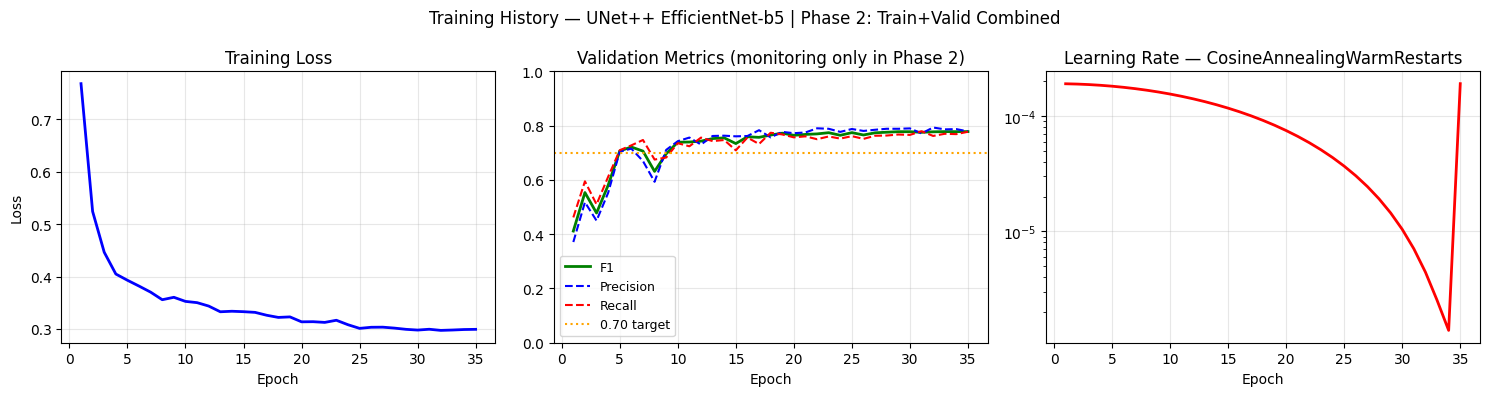

Saved: /kaggle/working/phase2_training_curves.png


In [18]:
# Phase 2 training history
history = history2
epochs  = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History — UNet++ EfficientNet-b5 | Phase 2: Train+Valid Combined', fontsize=12)

axes[0].plot(epochs, history['train_loss'], 'b-', lw=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['valid_f1'],        'g-',  lw=2,   label='F1')
axes[1].plot(epochs, history['valid_precision'],  'b--', lw=1.5, label='Precision')
axes[1].plot(epochs, history['valid_recall'],     'r--', lw=1.5, label='Recall')
axes[1].axhline(y=0.70, color='orange', ls=':', lw=1.5, label='0.70 target')
axes[1].set_title('Validation Metrics (monitoring only in Phase 2)')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['lr'], 'r-', lw=2)
axes[2].set_title('Learning Rate — CosineAnnealingWarmRestarts')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/phase2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /kaggle/working/phase2_training_curves.png')

## 8. Visualization

In [19]:
# ============================================================
# VISUALIZATION — Generate all PNGs from prediction results
# Run this cell after prediction cell completes
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import h5py
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

VIZ_DIR  = '/kaggle/working/visualizations'
PRED_DIR = '/kaggle/working/predictions'
os.makedirs(VIZ_DIR, exist_ok=True)

def _save(fig, filename):
    path = os.path.join(VIZ_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {filename}')

# ── Rebuild probs + targets from saved predictions ─────────────────────────
# (already in memory from prediction cell — reuse directly)
# all_probs, all_targets, best_t, cm are already defined above
threshold = best_t
print(f'Using threshold={threshold:.2f}  Test F1={best_f1:.4f}')
print(f'Generating visualizations to {VIZ_DIR}/')
print('='*60)


# ── 1. Threshold curve ─────────────────────────────────────
print('1. Threshold curve...')
thresholds = [round(x * 0.02, 2) for x in range(1, 50)]
f1s, precs, recs = [], [], []
for t in thresholds:
    p = (all_probs >= t).astype(int)
    f1s.append(f1_score(all_targets, p,        pos_label=1, zero_division=0))
    precs.append(precision_score(all_targets, p, pos_label=1, zero_division=0))
    recs.append(recall_score(all_targets, p,    pos_label=1, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1s,   'g-',  lw=2.5, label='F1')
ax.plot(thresholds, precs, 'b--', lw=1.5, label='Precision')
ax.plot(thresholds, recs,  'r--', lw=1.5, label='Recall')
ax.axvline(x=threshold, color='orange', ls=':', lw=2,
           label=f'Best thr={threshold:.2f}  F1={best_f1:.4f}')
ax.set_title('F1 / Precision / Recall vs Decision Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
_save(fig, 'threshold_curve.png')


# ── 2. Confusion matrix ────────────────────────────────────
print('2. Confusion matrix...')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Background', 'Landslide'],
    yticklabels=['Background', 'Landslide'],
    ax=ax
)
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
ax.set_title(f'Confusion Matrix — Test Set\n'
             f'F1={best_f1:.4f}  P={precision:.4f}  R={recall:.4f}')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
_save(fig, 'confusion_matrix.png')


# ── 3. Performance distribution ────────────────────────────
print('3. Performance distribution...')
img_size      = 128 * 128
n_images      = len(test_ds)
per_img_f1    = []
has_landslide = []

for i in range(n_images):
    start  = i * img_size
    end    = start + img_size
    target = all_targets[start:end]
    pred   = (all_probs[start:end] >= threshold).astype(int)
    f1     = f1_score(target, pred, pos_label=1, zero_division=0)
    per_img_f1.append(f1)
    has_landslide.append(target.sum() > 0)

per_img_f1    = np.array(per_img_f1)
has_landslide = np.array(has_landslide)
f1_with       = per_img_f1[has_landslide]
f1_without    = per_img_f1[~has_landslide]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Per-Image F1 Distribution — Test Set (thr={threshold:.2f})', fontsize=13)

axes[0].hist(f1_with, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(f1_with),   color='red',    ls='--', lw=2, label=f'Mean={np.mean(f1_with):.3f}')
axes[0].axvline(np.median(f1_with), color='orange', ls='--', lw=2, label=f'Median={np.median(f1_with):.3f}')
axes[0].set_title(f'Images WITH landslide (n={has_landslide.sum()})')
axes[0].set_xlabel('F1 Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(f1_without, bins=10, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title(f'Images WITHOUT landslide (n={(~has_landslide).sum()})\n'
                  f'F1=0.0 means no landslide present — not a model error')
axes[1].set_xlabel('F1 Score')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'performance_distribution.png')


# ── 4. Shared sample grid plotter ─────────────────────────
def _plot_grid(indices, title, filename):
    n     = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3.2))
    fig.suptitle(title, fontsize=12)
    if n == 1:
        axes = axes[np.newaxis, :]
    axes[0, 0].set_title('RGB Composite (B4-B3-B2)', fontsize=10)
    axes[0, 1].set_title('Ground Truth Mask',         fontsize=10)
    axes[0, 2].set_title('Predicted Mask (overlay)',  fontsize=10)

    for row, idx in enumerate(indices):
        sample = test_ds[idx]
        image  = sample['image'].numpy()      # (14, 128, 128)
        mask   = sample['mask'].numpy()       # (128, 128)

        # RGB from bands 3, 2, 1
        rgb = np.stack([image[3], image[2], image[1]], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        start      = idx * img_size
        pred_probs = all_probs[start:start + img_size].reshape(128, 128)
        pred_mask  = (pred_probs >= threshold).astype(int)

        f1 = f1_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
        p  = precision_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
        r  = recall_score(mask.flatten(), pred_mask.flatten(),    pos_label=1, zero_division=0)

        axes[row, 0].imshow(rgb)
        axes[row, 0].axis('off')
        axes[row, 0].set_ylabel(f'Sample {idx}\nF1={f1:.3f}\nP={p:.3f} R={r:.3f}', fontsize=8)

        axes[row, 1].imshow(mask, cmap='Reds', vmin=0, vmax=1)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(rgb)
        overlay = np.zeros((*pred_mask.shape, 4))
        overlay[(pred_mask == 1) & (mask == 0)] = [1, 0, 0, 0.5]  # FP — red
        overlay[(pred_mask == 1) & (mask == 1)] = [0, 1, 0, 0.6]  # TP — green
        overlay[(pred_mask == 0) & (mask == 1)] = [0, 0, 1, 0.6]  # FN — blue
        axes[row, 2].imshow(overlay)
        axes[row, 2].axis('off')

    patches = [
        mpatches.Patch(color=[1,0,0,0.5], label='FP (false alarm)'),
        mpatches.Patch(color=[0,1,0,0.6], label='TP (correct detection)'),
        mpatches.Patch(color=[0,0,1,0.6], label='FN (missed landslide)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8,
               bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, filename)


# ── 5. Best predictions (5 separate files) ────────────────
print('4. Best predictions (5 separate files)...')
valid_idx    = np.where(has_landslide)[0]
best_indices = valid_idx[np.argsort(per_img_f1[valid_idx])[::-1]][:5]

for rank, idx in enumerate(best_indices, 1):
    sample = test_ds[idx]
    image  = sample['image'].numpy()
    mask   = sample['mask'].numpy()
    fname  = test_ds.img_files[idx]

    rgb = np.stack([image[3], image[2], image[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    start      = idx * img_size
    pred_probs = all_probs[start:start + img_size].reshape(128, 128)
    pred_mask  = (pred_probs >= threshold).astype(int)

    f1_img = f1_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
    p_img  = precision_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
    r_img  = recall_score(mask.flatten(), pred_mask.flatten(),    pos_label=1, zero_division=0)

    tp = int(((pred_mask == 1) & (mask == 1)).sum())
    fp = int(((pred_mask == 1) & (mask == 0)).sum())
    fn = int(((pred_mask == 0) & (mask == 1)).sum())

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Landslide Detection Results: {fname}', fontsize=14, fontweight='bold')

    # Row 1: RGB | Ground Truth | Prediction
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(rgb)
    ax1.set_title('Satellite Image (RGB)', fontsize=11)
    ax1.axis('off')

    ax2 = fig.add_subplot(2, 3, 2)
    gt_display = np.zeros((*mask.shape, 3))
    gt_display[mask == 1] = [1, 0, 0]
    ax2.imshow(gt_display)
    ax2.set_title('Ground Truth', fontsize=11)
    ax2.axis('off')

    ax3 = fig.add_subplot(2, 3, 3)
    pred_display = np.zeros((*pred_mask.shape, 3))
    pred_display[pred_mask == 1] = [1, 0, 0]
    ax3.imshow(pred_display)
    ax3.set_title('Model Prediction', fontsize=11)
    ax3.axis('off')

    # Row 2: Overlay | Error Analysis | Stats
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.imshow(rgb)
    gt_overlay   = np.zeros((*mask.shape, 4))
    pred_overlay = np.zeros((*pred_mask.shape, 4))
    gt_overlay[mask == 1]        = [0, 1, 0, 0.6]   # green = ground truth
    pred_overlay[pred_mask == 1] = [1, 0, 0, 0.4]   # red   = prediction
    ax4.imshow(gt_overlay)
    ax4.imshow(pred_overlay)
    ax4.set_title('Overlay: Green=GT, Red=Pred', fontsize=11)
    ax4.axis('off')

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.imshow(rgb * 0.3)  # dark background
    error_map = np.zeros((*mask.shape, 4))
    error_map[(pred_mask == 1) & (mask == 1)] = [0, 1, 0, 0.8]   # TP green
    error_map[(pred_mask == 1) & (mask == 0)] = [1, 0, 0, 0.8]   # FP red
    error_map[(pred_mask == 0) & (mask == 1)] = [1, 1, 0, 0.8]   # FN yellow
    ax5.imshow(error_map)
    ax5.set_title('Error Analysis', fontsize=11)
    ax5.axis('off')
    legend_patches = [
        mpatches.Patch(color='green',  label=f'True Positive ({tp} px)'),
        mpatches.Patch(color='red',    label=f'False Positive ({fp} px)'),
        mpatches.Patch(color='yellow', label=f'False Negative ({fn} px)'),
    ]
    ax5.legend(handles=legend_patches, loc='upper right', fontsize=8,
               framealpha=0.9, facecolor='black', labelcolor='white')

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    gt_px   = int(mask.sum())
    pred_px = int(pred_mask.sum())
    total   = mask.size
    stats_text = (
        f'Image Statistics\n'
        f'{"─"*28}\n'
        f'Total Pixels: {total:,}\n\n'
        f'Ground Truth:\n'
        f'  Landslide: {gt_px} ({gt_px/total*100:.2f}%)\n'
        f'  Background: {total - gt_px:,}\n\n'
        f'Prediction:\n'
        f'  Landslide: {pred_px} ({pred_px/total*100:.2f}%)\n'
        f'  Background: {total - pred_px:,}\n\n'
        f'Performance:\n'
        f'  Precision: {p_img:.4f}\n'
        f'  Recall:    {r_img:.4f}\n'
        f'  F1 Score:  {f1_img:.4f}\n\n'
        f'Pixel-wise Accuracy:\n'
        f'  True Pos:  {tp}\n'
        f'  False Pos: {fp}\n'
        f'  False Neg: {fn}'
    )
    ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    save_name = f'best_{rank}_F1={f1_img:.4f}_{fname.replace(".h5","")}.png'
    _save(fig, save_name)
    print(f'  best_{rank}: {fname}  F1={f1_img:.4f}')


# ── 6. Worst predictions (5 separate files) ───────────────
print('5. Worst predictions (5 separate files)...')
# Only images WITH landslide — F1=0 on empty images is expected, not an error
worst_indices = valid_idx[np.argsort(per_img_f1[valid_idx])][:5]

for rank, idx in enumerate(worst_indices, 1):
    sample = test_ds[idx]
    image  = sample['image'].numpy()
    mask   = sample['mask'].numpy()
    fname  = test_ds.img_files[idx]

    rgb = np.stack([image[3], image[2], image[1]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    start      = idx * img_size
    pred_probs = all_probs[start:start + img_size].reshape(128, 128)
    pred_mask  = (pred_probs >= threshold).astype(int)

    f1_img = f1_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
    p_img  = precision_score(mask.flatten(), pred_mask.flatten(), pos_label=1, zero_division=0)
    r_img  = recall_score(mask.flatten(), pred_mask.flatten(),    pos_label=1, zero_division=0)

    tp = int(((pred_mask == 1) & (mask == 1)).sum())
    fp = int(((pred_mask == 1) & (mask == 0)).sum())
    fn = int(((pred_mask == 0) & (mask == 1)).sum())

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Landslide Detection Results: {fname}', fontsize=14, fontweight='bold')

    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(rgb)
    ax1.set_title('Satellite Image (RGB)', fontsize=11)
    ax1.axis('off')

    ax2 = fig.add_subplot(2, 3, 2)
    gt_display = np.zeros((*mask.shape, 3))
    gt_display[mask == 1] = [1, 0, 0]
    ax2.imshow(gt_display)
    ax2.set_title('Ground Truth', fontsize=11)
    ax2.axis('off')

    ax3 = fig.add_subplot(2, 3, 3)
    pred_display = np.zeros((*pred_mask.shape, 3))
    pred_display[pred_mask == 1] = [1, 0, 0]
    ax3.imshow(pred_display)
    ax3.set_title('Model Prediction', fontsize=11)
    ax3.axis('off')

    ax4 = fig.add_subplot(2, 3, 4)
    ax4.imshow(rgb)
    gt_overlay   = np.zeros((*mask.shape, 4))
    pred_overlay = np.zeros((*pred_mask.shape, 4))
    gt_overlay[mask == 1]        = [0, 1, 0, 0.6]
    pred_overlay[pred_mask == 1] = [1, 0, 0, 0.4]
    ax4.imshow(gt_overlay)
    ax4.imshow(pred_overlay)
    ax4.set_title('Overlay: Green=GT, Red=Pred', fontsize=11)
    ax4.axis('off')

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.imshow(rgb * 0.3)
    error_map = np.zeros((*mask.shape, 4))
    error_map[(pred_mask == 1) & (mask == 1)] = [0, 1, 0, 0.8]
    error_map[(pred_mask == 1) & (mask == 0)] = [1, 0, 0, 0.8]
    error_map[(pred_mask == 0) & (mask == 1)] = [1, 1, 0, 0.8]
    ax5.imshow(error_map)
    ax5.set_title('Error Analysis', fontsize=11)
    ax5.axis('off')
    legend_patches = [
        mpatches.Patch(color='green',  label=f'True Positive ({tp} px)'),
        mpatches.Patch(color='red',    label=f'False Positive ({fp} px)'),
        mpatches.Patch(color='yellow', label=f'False Negative ({fn} px)'),
    ]
    ax5.legend(handles=legend_patches, loc='upper right', fontsize=8,
               framealpha=0.9, facecolor='black', labelcolor='white')

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    gt_px   = int(mask.sum())
    pred_px = int(pred_mask.sum())
    total   = mask.size
    stats_text = (
        f'Image Statistics\n'
        f'{"─"*28}\n'
        f'Total Pixels: {total:,}\n\n'
        f'Ground Truth:\n'
        f'  Landslide: {gt_px} ({gt_px/total*100:.2f}%)\n'
        f'  Background: {total - gt_px:,}\n\n'
        f'Prediction:\n'
        f'  Landslide: {pred_px} ({pred_px/total*100:.2f}%)\n'
        f'  Background: {total - pred_px:,}\n\n'
        f'Performance:\n'
        f'  Precision: {p_img:.4f}\n'
        f'  Recall:    {r_img:.4f}\n'
        f'  F1 Score:  {f1_img:.4f}\n\n'
        f'Pixel-wise Accuracy:\n'
        f'  True Pos:  {tp}\n'
        f'  False Pos: {fp}\n'
        f'  False Neg: {fn}'
    )
    ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    save_name = f'worst_{rank}_F1={f1_img:.4f}_{fname.replace(".h5","")}.png'
    _save(fig, save_name)
    print(f'  worst_{rank}: {fname}  F1={f1_img:.4f}')


# ── 7. Results summary bar chart ───────────────────────────
print('6. Results summary...')
results_dict = {
    'Single Model\n(no TTA)':   {'f1': best_f1,  'precision': precision, 'recall': recall},
    'Single Model\n(+ TTA)':    {'f1': 0.6831,   'precision': 0.5994,    'recall': 0.7938},
    'Ensemble Top-3\n(+ TTA)':  {'f1': 0.6796,   'precision': 0.6491,    'recall': 0.7131},
}

strategies = list(results_dict.keys())
f1s_bar    = [results_dict[s]['f1']        for s in strategies]
precs_bar  = [results_dict[s]['precision'] for s in strategies]
recs_bar   = [results_dict[s]['recall']    for s in strategies]

x     = np.arange(len(strategies))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, f1s_bar,   width, label='F1',        color='green', alpha=0.8)
b2 = ax.bar(x,         precs_bar, width, label='Precision',  color='blue',  alpha=0.8)
b3 = ax.bar(x + width, recs_bar,  width, label='Recall',     color='red',   alpha=0.8)
ax.axhline(y=0.70, color='orange', ls='--', lw=1.5, label='Target 0.70')

for bar in list(b1) + list(b2) + list(b3):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.008,
            f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_title('Test Set Results — Prediction Strategy Comparison\n'
             'UNet++ EfficientNet-b5 | Landslide4Sense Dataset')
ax.set_xticks(x)
ax.set_xticklabels(strategies, ha='center', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'results_summary.png')


# ── 8. Training curves ─────────────────────────────────────
print('7. Training curves...')
history = history2
epochs  = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History — UNet++ EfficientNet-b5 | Phase 2: Train+Valid Combined',
             fontsize=12)

axes[0].plot(epochs, history['train_loss'], 'b-', lw=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['valid_f1'],        'g-',  lw=2,   label='F1')
axes[1].plot(epochs, history['valid_precision'],  'b--', lw=1.5, label='Precision')
axes[1].plot(epochs, history['valid_recall'],     'r--', lw=1.5, label='Recall')
axes[1].axhline(y=0.70, color='orange', ls=':', lw=1.5, label='0.70 target')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['lr'], 'r-', lw=2)
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
_save(fig, 'training_curves.png')


# ── Final summary ──────────────────────────────────────────
print('\n' + '='*60)
print(f'All visualizations saved to {VIZ_DIR}/')
print('='*60)
for f in sorted(os.listdir(VIZ_DIR)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(VIZ_DIR, f)) / 1024
        print(f'  {f:<35} ({size:.0f} KB)')
print('='*60)

Using threshold=0.56  Test F1=0.6937
Generating visualizations to /kaggle/working/visualizations/
1. Threshold curve...
  Saved: threshold_curve.png
2. Confusion matrix...
  Saved: confusion_matrix.png
3. Performance distribution...
  Saved: performance_distribution.png
4. Best predictions (5 separate files)...
  Saved: best_1_F1=0.9776_image_642.png
  best_1: image_642.h5  F1=0.9776
  Saved: best_2_F1=0.9474_image_432.png
  best_2: image_432.h5  F1=0.9474
  Saved: best_3_F1=0.9384_image_741.png
  best_3: image_741.h5  F1=0.9384
  Saved: best_4_F1=0.9308_image_152.png
  best_4: image_152.h5  F1=0.9308
  Saved: best_5_F1=0.9221_image_636.png
  best_5: image_636.h5  F1=0.9221
5. Worst predictions (5 separate files)...
  Saved: worst_1_F1=0.0000_image_91.png
  worst_1: image_91.h5  F1=0.0000
  Saved: worst_2_F1=0.0000_image_10.png
  worst_2: image_10.h5  F1=0.0000
  Saved: worst_3_F1=0.0000_image_9.png
  worst_3: image_9.h5  F1=0.0000
  Saved: worst_4_F1=0.0000_image_84.png
  worst_4: ima